reference:

https://github.com/prashanth092/Backup_Automation_Multpile_Vendor_using_Netmiko/blob/main/Exercise.py


https://www.linkedin.com/posts/prashanth-boyapothula-22bba21a3_automating-network-configuration-backups-share-7492467059076022272-aVsT/?utm_source=social_share_send&utm_medium=android_app&rcm=ACoAAC8IlrcBmvwrYuN0lmHmfRzYLS7LMrEqaGM&utm_campaign=share_via&skipRedirect=true


Automating Network Configuration Backups with Python & Netmiko 
As part of my network operations work, I wanted to reduce the repetitive effort involved in manually connecting to network devices and collecting configuration backups.
So, I built a Python-based Network Configuration Backup Automation using Python, Pandas and Netmiko and used it to successfully perform backups of Cisco switches and Fortinet firewalls.
->What the automation does here is 
The script reads device information from a CSV inventory and automatically:
Connects to devices using SSH
Uses Netmiko for device connectivity
Identifies the device type
Executes the appropriate configuration command
Collects the configuration
Creates an individual backup file
Includes hostname and IP address in the filename
Disconnects after the backup
-> Multi-Vendor Support
Cisco Switches
show running-config
Fortinet Firewalls
show full-configuration
The device type is maintained in the CSV, allowing the same Python script to handle different network platforms.
For example:
SW01_10.10.10.10_backup.txt
This provides a consistent way to identify and organize configuration backups.
-> Actual Implementation
This was not just a sample script. I created the automation, tested it, and used it for actual configuration backups of Cisco switches and Fortinet firewalls.
It was a good practical use case for applying Python automation to reduce repetitive manual work in network operations.

I’ve also uploaded the complete script to GitHub.
https://lnkd.in/dA4XFmbh

Small automation → real time code


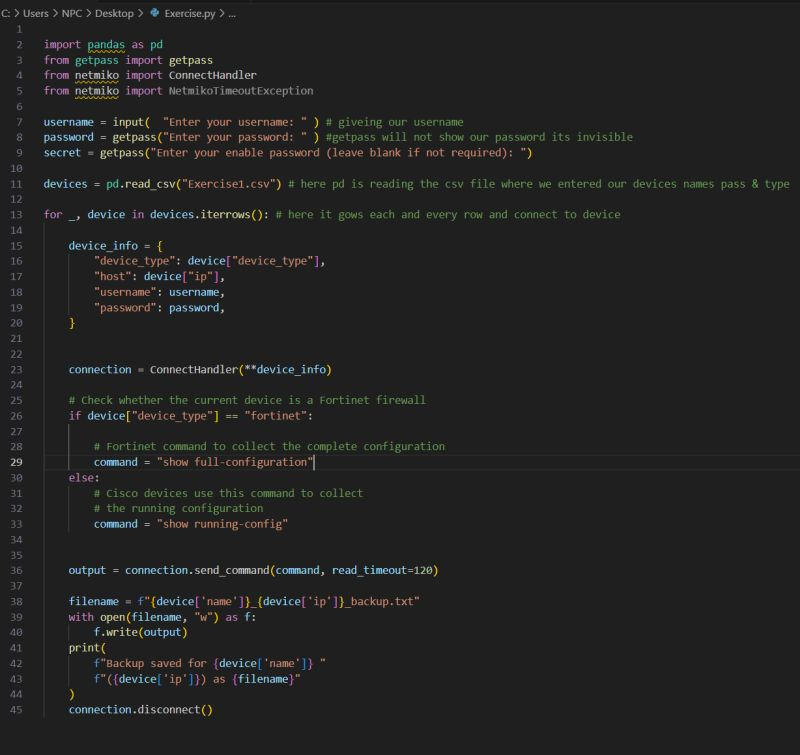

In [4]:
!pip install pandas


Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
!pip install getpass

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/


ERROR: Could not find a version that satisfies the requirement getpass (from versions: none)

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for getpass


In [6]:
!pip install netmiko

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://packagefeedproxy.microsoft.io/pypi/simple/



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import yaml

with open("devices.yaml", "r") as file:
    devices = yaml.safe_load(file)


In [5]:
import yaml

from getpass import getpass

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)


# ---------------------------------------------------
# Get username and password
# ---------------------------------------------------

username = input("Enter your username: ")

password = getpass("Enter your password: ")

secret = getpass(
    "Enter enable password (leave blank if not required): "
)


# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("devices.yaml", "r") as file:
    data = yaml.safe_load(file)

devices = data["routers"]


# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)
    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )
    print("=" * 60)

    try:

        # Build Netmiko device dictionary
        device_info = {
            "device_type": device["device_type"],
            "host": device["host"],
            "username": username,
            "password": password,
            "secret": secret
        }


        # Try SSH connection
        connection = ConnectHandler(**device_info)


        print(
            f"Connected successfully to {device['name']}"
        )


        # Enter enable mode if secret was provided
        if secret:
            connection.enable()


        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":

            command = "show full-configuration"

        else:

            command = "show running-config"


        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(
            command,
            read_timeout=120
        )


        # ---------------------------------------------------
        # Backup filename
        # ---------------------------------------------------

        filename = (
            f"{device['name']}_"
            f"{device['host']}_backup.txt"
        )


        # Save configuration
        with open(filename, "w") as file:

            file.write(output)


        print(
            f"Backup successfully saved: {filename}"
        )


        # Disconnect
        connection.disconnect()


    # ---------------------------------------------------
    # Device unreachable / SSH timeout
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) is NOT AVAILABLE."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Wrong username/password
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} ({device['host']})."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with {device['name']} "
            f"({device['host']}): {error}"
        )

        print("Skipping this device...")


# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)
print("Backup process completed.")
print("=" * 60)


Trying to connect to R1 (192.168.32.141)
Connected successfully to R1
Backup successfully saved: R1_192.168.32.141_backup.txt

Trying to connect to R2 (192.168.32.140)
Connected successfully to R2
Backup successfully saved: R2_192.168.32.140_backup.txt

Backup process completed.


In [6]:
import yaml

from datetime import datetime
from getpass import getpass

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)


# ---------------------------------------------------
# Get username and password
# ---------------------------------------------------

username = input("Enter your username: ")

password = getpass("Enter your password: ")

secret = getpass(
    "Enter enable password "
    "(leave blank if not required): "
)


# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("devices.yaml", "r") as file:

    data = yaml.safe_load(file)


devices = data["routers"]


# ---------------------------------------------------
# Create timestamp for this backup run
# ---------------------------------------------------

timestamp = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)


# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)

    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )

    print("=" * 60)


    try:

        # ---------------------------------------------------
        # Build Netmiko device dictionary
        # ---------------------------------------------------

        device_info = {

            "device_type": device["device_type"],

            "host": device["host"],

            "username": username,

            "password": password,

            "secret": secret
        }


        # ---------------------------------------------------
        # Connect to device
        # ---------------------------------------------------

        connection = ConnectHandler(
            **device_info
        )


        print(
            f"Connected successfully to "
            f"{device['name']}"
        )


        # ---------------------------------------------------
        # Enter enable mode if required
        # ---------------------------------------------------

        if secret:

            connection.enable()


        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":

            command = "show full-configuration"

        else:

            command = "show running-config"


        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(

            command,

            read_timeout=120
        )


        # ---------------------------------------------------
        # Create backup filename
        # ---------------------------------------------------

        filename = (

            f"{device['name']}_"

            f"{device['host']}_backup_"

            f"{timestamp}.txt"
        )


        # ---------------------------------------------------
        # Save backup
        # "x" prevents existing files from being overwritten
        # ---------------------------------------------------

        with open(filename, "x") as backup_file:

            backup_file.write(output)


        print(
            f"Backup successfully saved: "
            f"{filename}"
        )


        # ---------------------------------------------------
        # Disconnect
        # ---------------------------------------------------

        connection.disconnect()


    # ---------------------------------------------------
    # Device unavailable
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) "
            f"is NOT AVAILABLE."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Authentication failure
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} "
            f"({device['host']})."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Backup file already exists
    # ---------------------------------------------------

    except FileExistsError:

        print(
            f"❌ Backup file already exists "
            f"for {device['name']}."
        )

        print(
            "Old backup was NOT modified."
        )


    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with "
            f"{device['name']} "
            f"({device['host']}): "
            f"{error}"
        )

        print("Skipping this device...")


# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)

print("Backup process completed.")

print("=" * 60)


Trying to connect to R1 (192.168.32.141)
Connected successfully to R1
Backup successfully saved: R1_192.168.32.141_backup_2026-08-11_10-29-26.txt

Trying to connect to R2 (192.168.32.140)
Connected successfully to R2
Backup successfully saved: R2_192.168.32.140_backup_2026-08-11_10-29-26.txt

Backup process completed.


Yes. The best change is to add a **timestamp** to the filename.

Use Python's `datetime` module and generate a timestamp like:

```text
2026-08-11_10-24-35
```

Then your files will look like:

```text
R1_192.168.32.141_backup_2026-08-11_10-24-35.txt
R2_192.168.32.140_backup_2026-08-11_10-24-35.txt
```

If you run the script again later:

```text
R1_192.168.32.141_backup_2026-08-11_10-30-12.txt
R2_192.168.32.140_backup_2026-08-11_10-30-12.txt
```

So the previous files are not touched or overwritten.

Add this import at the top:

```python
from datetime import datetime
```

Then replace your current filename section:

```python
filename = (
    f"{device['name']}_"
    f"{device['host']}_backup.txt"
)
```

with:

```python
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

filename = (
    f"{device['name']}_"
    f"{device['host']}_backup_"
    f"{timestamp}.txt"
)
```

I would also recommend using `"x"` mode instead of `"w"` mode when creating the file.

You currently have:

```python
with open(filename, "w") as file:
    file.write(output)
```

Change it to:

```python
with open(filename, "x") as file:
    file.write(output)
```

The difference is important:

```text
"w" = write mode
      creates file
      BUT overwrites it if the filename already exists

"x" = exclusive create mode
      creates a NEW file
      raises an error if that filename already exists
```

That gives you an extra protection layer.

So your final backup section should be:

```python
from datetime import datetime


# ---------------------------------------------------
# Create timestamp
# ---------------------------------------------------

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


# ---------------------------------------------------
# Create backup filename
# ---------------------------------------------------

filename = (
    f"{device['name']}_"
    f"{device['host']}_backup_"
    f"{timestamp}.txt"
)


# ---------------------------------------------------
# Save configuration
# ---------------------------------------------------

with open(filename, "x") as file:

    file.write(output)


print(
    f"Backup successfully saved: {filename}"
)
```

### Your complete modified script

```python
import yaml

from datetime import datetime
from getpass import getpass

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)


# ---------------------------------------------------
# Get username and password
# ---------------------------------------------------

username = input("Enter your username: ")

password = getpass("Enter your password: ")

secret = getpass(
    "Enter enable password "
    "(leave blank if not required): "
)


# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("devices.yaml", "r") as file:

    data = yaml.safe_load(file)


devices = data["routers"]


# ---------------------------------------------------
# Create timestamp for this backup run
# ---------------------------------------------------

timestamp = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)


# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)

    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )

    print("=" * 60)


    try:

        # ---------------------------------------------------
        # Build Netmiko device dictionary
        # ---------------------------------------------------

        device_info = {

            "device_type": device["device_type"],

            "host": device["host"],

            "username": username,

            "password": password,

            "secret": secret
        }


        # ---------------------------------------------------
        # Connect to device
        # ---------------------------------------------------

        connection = ConnectHandler(
            **device_info
        )


        print(
            f"Connected successfully to "
            f"{device['name']}"
        )


        # ---------------------------------------------------
        # Enter enable mode if required
        # ---------------------------------------------------

        if secret:

            connection.enable()


        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":

            command = "show full-configuration"

        else:

            command = "show running-config"


        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(

            command,

            read_timeout=120
        )


        # ---------------------------------------------------
        # Create backup filename
        # ---------------------------------------------------

        filename = (

            f"{device['name']}_"

            f"{device['host']}_backup_"

            f"{timestamp}.txt"
        )


        # ---------------------------------------------------
        # Save backup
        # "x" prevents existing files from being overwritten
        # ---------------------------------------------------

        with open(filename, "x") as backup_file:

            backup_file.write(output)


        print(
            f"Backup successfully saved: "
            f"{filename}"
        )


        # ---------------------------------------------------
        # Disconnect
        # ---------------------------------------------------

        connection.disconnect()


    # ---------------------------------------------------
    # Device unavailable
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) "
            f"is NOT AVAILABLE."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Authentication failure
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} "
            f"({device['host']})."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Backup file already exists
    # ---------------------------------------------------

    except FileExistsError:

        print(
            f"❌ Backup file already exists "
            f"for {device['name']}."
        )

        print(
            "Old backup was NOT modified."
        )


    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with "
            f"{device['name']} "
            f"({device['host']}): "
            f"{error}"
        )

        print("Skipping this device...")


# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)

print("Backup process completed.")

print("=" * 60)
```

A nice detail here is that I create the timestamp **once before the `for` loop**:

```python
timestamp = datetime.now().strftime(
    "%Y-%m-%d_%H-%M-%S"
)
```

That means R1 and R2 from the same backup run get exactly the same timestamp:

```text
R1_192.168.32.141_backup_2026-08-11_10-30-12.txt
R2_192.168.32.140_backup_2026-08-11_10-30-12.txt
```

That makes it very easy to identify that both files belong to the **same backup run**.

Then if you run it again at 10:45:

```text
R1_192.168.32.141_backup_2026-08-11_10-45-07.txt
R2_192.168.32.140_backup_2026-08-11_10-45-07.txt
```

Your old `10-30-12` files remain completely unchanged.




In [7]:
import yaml
from datetime import datetime
from getpass import getpass

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)

# ---------------------------------------------------
# Get username and password
# ---------------------------------------------------

username = input("Enter your username: ")

password = getpass("Enter your password: ")

secret = getpass(
    "Enter enable password (leave blank if not required): "
)

# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("devices.yaml", "r") as file:
    data = yaml.safe_load(file)

devices = data["routers"]

# ---------------------------------------------------
# Generate timestamp for this backup run
# ---------------------------------------------------

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)
    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )
    print("=" * 60)

    try:

        # Build Netmiko device dictionary
        device_info = {
            "device_type": device["device_type"],
            "host": device["host"],
            "username": username,
            "password": password,
            "secret": secret
        }

        # Try SSH connection
        connection = ConnectHandler(**device_info)

        print(
            f"Connected successfully to {device['name']}"
        )

        # Enter enable mode if secret was provided
        if secret:
            connection.enable()

        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":
            command = "show full-configuration"
        else:
            command = "show running-config"

        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(
            command,
            read_timeout=120
        )

        # ---------------------------------------------------
        # Backup filename
        # ---------------------------------------------------

        filename = (
            f"{device['name']}_"
            f"{device['host']}_"
            f"{timestamp}_backup.txt"
        )

        # ---------------------------------------------------
        # Save configuration
        # ---------------------------------------------------

        with open(filename, "w") as file:
            file.write(output)

        print(
            f"Backup successfully saved: {filename}"
        )

        # Disconnect
        connection.disconnect()

    # ---------------------------------------------------
    # Device unreachable / SSH timeout
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) is NOT AVAILABLE."
        )

        print("Skipping this device...")

    # ---------------------------------------------------
    # Wrong username/password
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} ({device['host']})."
        )

        print("Skipping this device...")

    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with {device['name']} "
            f"({device['host']}): {error}"
        )

        print("Skipping this device...")

# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)
print("Backup process completed.")
print("=" * 60)


Trying to connect to R1 (192.168.32.141)
Connected successfully to R1
Backup successfully saved: R1_192.168.32.141_2026-08-11_10-31-43_backup.txt

Trying to connect to R2 (192.168.32.140)
Connected successfully to R2
Backup successfully saved: R2_192.168.32.140_2026-08-11_10-31-43_backup.txt

Backup process completed.


Yes. Right now your code uses:

filename = (
    f"{device['name']}_"
    f"{device['host']}_backup.txt"
)


and later:

with open(filename, "w") as file:


Since the filename is always the same, running the script again overwrites the existing file.

Fix: Add Timestamp to the Filename

Add this import at the top:

from datetime import datetime


Then replace your filename section with:

# Current date and time
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Backup filename
filename = (
    f"{device['name']}_"
    f"{device['host']}_"
    f"{timestamp}_backup.txt"
)

Example Output

First run at 6:30:15 PM:

R1_192.168.32.141_20260811_183015_backup.txt
R2_192.168.32.140_20260811_183015_backup.txt


Second run at 6:45:22 PM:

R1_192.168.32.141_20260811_184522_backup.txt
R2_192.168.32.140_20260811_184522_backup.txt


Nothing gets overwritten because every filename is unique.

Even Better (Human Readable)
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

filename = (
    f"{device['name']}_"
    f"{device['host']}_"
    f"{timestamp}_backup.txt"
)


Example:

R1_192.168.32.141_2026-08-11_18-30-15_backup.txt
R2_192.168.32.140_2026-08-11_18-30-15_backup.txt

Optional: Store Backups in a Separate Folder
import os

os.makedirs("backups", exist_ok=True)

filename = (
    f"backups/{device['name']}_"
    f"{device['host']}_"
    f"{timestamp}_backup.txt"
)


This will create:

backups/
├── R1_192.168.32.141_2026-08-11_18-30-15_backup.txt
├── R1_192.168.32.141_2026-08-11_18-45-22_backup.txt
├── R2_192.168.32.140_2026-08-11_18-30-15_backup.txt
└── R2_192.168.32.140_2026-08-11_18-45-22_backup.txt


This is the method I would recommend for network device backups because it preserves every backup run and never modifies older files.



Absolutely. Below is your complete code with the timestamp functionality added so that every run creates a new backup file and never overwrites an existing backup.

import yaml
from datetime import datetime
from getpass import getpass

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)

# ---------------------------------------------------
# Get username and password
# ---------------------------------------------------

username = input("Enter your username: ")

password = getpass("Enter your password: ")

secret = getpass(
    "Enter enable password (leave blank if not required): "
)

# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("devices.yaml", "r") as file:
    data = yaml.safe_load(file)

devices = data["routers"]

# ---------------------------------------------------
# Generate timestamp for this backup run
# ---------------------------------------------------

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)
    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )
    print("=" * 60)

    try:

        # Build Netmiko device dictionary
        device_info = {
            "device_type": device["device_type"],
            "host": device["host"],
            "username": username,
            "password": password,
            "secret": secret
        }

        # Try SSH connection
        connection = ConnectHandler(**device_info)

        print(
            f"Connected successfully to {device['name']}"
        )

        # Enter enable mode if secret was provided
        if secret:
            connection.enable()

        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":
            command = "show full-configuration"
        else:
            command = "show running-config"

        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(
            command,
            read_timeout=120
        )

        # ---------------------------------------------------
        # Backup filename
        # ---------------------------------------------------

        filename = (
            f"{device['name']}_"
            f"{device['host']}_"
            f"{timestamp}_backup.txt"
        )

        # ---------------------------------------------------
        # Save configuration
        # ---------------------------------------------------

        with open(filename, "w") as file:
            file.write(output)

        print(
            f"Backup successfully saved: {filename}"
        )

        # Disconnect
        connection.disconnect()

    # ---------------------------------------------------
    # Device unreachable / SSH timeout
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) is NOT AVAILABLE."
        )

        print("Skipping this device...")

    # ---------------------------------------------------
    # Wrong username/password
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} ({device['host']})."
        )

        print("Skipping this device...")

    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with {device['name']} "
            f"({device['host']}): {error}"
        )

        print("Skipping this device...")

# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)
print("Backup process completed.")
print("=" * 60)

Example files created

First run at 10:15:30:

R1_192.168.32.141_2026-08-11_10-15-30_backup.txt
R2_192.168.32.140_2026-08-11_10-15-30_backup.txt


Second run at 10:40:12:

R1_192.168.32.141_2026-08-11_10-40-12_backup.txt
R2_192.168.32.140_2026-08-11_10-40-12_backup.txt


✅ Old files are never modified.
 ✅ New files are created every run.
 ✅ Easy to see exactly when each backup was taken.

As a next improvement for your network automation lab, I'd recommend creating a backups/ folder automatically and storing all backup files there so your project directory stays clean.

In [8]:
import yaml
from datetime import datetime
from getpass import getpass

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)

# ---------------------------------------------------
# Get username and password
# ---------------------------------------------------

username = input("Enter your username: ")

password = getpass("Enter your password: ")

secret = getpass(
    "Enter enable password (leave blank if not required): "
)

# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("cisco_fortinet.yaml", "r") as file:
    data = yaml.safe_load(file)

devices = data["routers"]

# ---------------------------------------------------
# Generate timestamp for this backup run
# ---------------------------------------------------

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)
    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )
    print("=" * 60)

    try:

        # Build Netmiko device dictionary
        device_info = {
            "device_type": device["device_type"],
            "host": device["host"],
            "username": username,
            "password": password,
            "secret": secret
        }

        # Try SSH connection
        connection = ConnectHandler(**device_info)

        print(
            f"Connected successfully to {device['name']}"
        )

        # Enter enable mode if secret was provided
        if secret:
            connection.enable()

        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":
            command = "show full-configuration"
        else:
            command = "show running-config"

        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(
            command,
            read_timeout=120
        )

        # ---------------------------------------------------
        # Backup filename
        # ---------------------------------------------------

        filename = (
            f"{device['name']}_"
            f"{device['host']}_"
            f"{timestamp}_backup.txt"
        )

        # ---------------------------------------------------
        # Save configuration
        # ---------------------------------------------------

        with open(filename, "w") as file:
            file.write(output)

        print(
            f"Backup successfully saved: {filename}"
        )

        # Disconnect
        connection.disconnect()

    # ---------------------------------------------------
    # Device unreachable / SSH timeout
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) is NOT AVAILABLE."
        )

        print("Skipping this device...")

    # ---------------------------------------------------
    # Wrong username/password
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} ({device['host']})."
        )

        print("Skipping this device...")

    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with {device['name']} "
            f"({device['host']}): {error}"
        )

        print("Skipping this device...")

# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)
print("Backup process completed.")
print("=" * 60)


Trying to connect to R1 (192.168.32.141)
Connected successfully to R1
Backup successfully saved: R1_192.168.32.141_2026-08-11_10-36-32_backup.txt

Trying to connect to R2 (192.168.32.140)
Connected successfully to R2
Backup successfully saved: R2_192.168.32.140_2026-08-11_10-36-32_backup.txt

Trying to connect to FW1 (192.168.32.150)
❌ Device FW1 (192.168.32.150) is NOT AVAILABLE.
Skipping this device...

Backup process completed.


Yes. Since `username`, `password`, and optionally `secret` are already in `devices.yaml`, you can read them directly from each `device` dictionary.

For example, your `devices.yaml` can be:

```yaml
routers:
  - name: R1
    device_type: cisco_ios
    host: 192.168.32.141
    username: admin
    password: admin123
    secret: EnablePassword123

  - name: R2
    device_type: cisco_ios
    host: 192.168.32.140
    username: admin
    password: admin123
    secret: EnablePassword123

  - name: FW1
    device_type: fortinet
    host: 192.168.32.150
    username: admin
    password: admin123
```

Then use this Python code:

```python
import yaml
from datetime import datetime

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)


# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("devices.yaml", "r") as file:
    data = yaml.safe_load(file)

devices = data["routers"]


# ---------------------------------------------------
# Generate timestamp for this backup run
# ---------------------------------------------------

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)

    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )

    print("=" * 60)

    try:

        # ---------------------------------------------------
        # Build Netmiko device dictionary
        # Credentials are read directly from devices.yaml
        # ---------------------------------------------------

        device_info = {
            "device_type": device["device_type"],
            "host": device["host"],
            "username": device["username"],
            "password": device["password"]
        }


        # ---------------------------------------------------
        # Add enable secret only if it exists in YAML
        # ---------------------------------------------------

        if device.get("secret"):

            device_info["secret"] = device["secret"]


        # ---------------------------------------------------
        # Try SSH connection
        # ---------------------------------------------------

        connection = ConnectHandler(**device_info)


        print(
            f"Connected successfully to "
            f"{device['name']}"
        )


        # ---------------------------------------------------
        # Enter enable mode only if secret exists
        # ---------------------------------------------------

        if device.get("secret"):

            connection.enable()


        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":

            command = "show full-configuration"

        else:

            command = "show running-config"


        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(
            command,
            read_timeout=120
        )


        # ---------------------------------------------------
        # Create backup filename
        # ---------------------------------------------------

        filename = (
            f"{device['name']}_"
            f"{device['host']}_"
            f"{timestamp}_backup.txt"
        )


        # ---------------------------------------------------
        # Save configuration
        #
        # "x" is used instead of "w".
        # This prevents an existing backup from being
        # accidentally overwritten.
        # ---------------------------------------------------

        with open(filename, "x") as backup_file:

            backup_file.write(output)


        print(
            f"Backup successfully saved: "
            f"{filename}"
        )


        # ---------------------------------------------------
        # Disconnect
        # ---------------------------------------------------

        connection.disconnect()


    # ---------------------------------------------------
    # Device unreachable / SSH timeout
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) is NOT AVAILABLE."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Wrong username/password
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} "
            f"({device['host']})."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Backup file already exists
    # ---------------------------------------------------

    except FileExistsError:

        print(
            f"❌ Backup file already exists for "
            f"{device['name']}."
        )

        print("Existing backup was NOT modified.")


    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with {device['name']} "
            f"({device['host']}): {error}"
        )

        print("Skipping this device...")


# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)

print("Backup process completed.")

print("=" * 60)
```

The important change is this part:

```python
device_info = {
    "device_type": device["device_type"],
    "host": device["host"],
    "username": device["username"],
    "password": device["password"]
}
```

Instead of:

```python
"username": username,
"password": password,
"secret": secret
```

Python now gets everything from YAML:

```text
devices.yaml
     │
     ├── name ──────────► R1
     ├── device_type ───► cisco_ios
     ├── host ──────────► 192.168.32.141
     ├── username ──────► admin
     ├── password ──────► admin123
     └── secret ────────► EnablePassword123
                              │
                              ▼
                      ConnectHandler()
                              │
                              ▼
                           Router
                              │
                              ▼
                    show running-config
                              │
                              ▼
                         Backup file
```

I also recommend this:

```python
if device.get("secret"):
    device_info["secret"] = device["secret"]
```

rather than:

```python
device["secret"]
```

because `.get()` allows `secret` to be missing from some devices. For example, your Fortinet can have no `secret`:

```yaml
- name: FW1
  device_type: fortinet
  host: 192.168.32.150
  username: admin
  password: admin123
```

The script will still work.

Also, I changed:

```python
with open(filename, "w")
```

to:

```python
with open(filename, "x")
```

This gives you an additional guarantee that **an existing backup file will never be overwritten**. Since your timestamp already creates a different filename on each run, `"x"` is a useful extra safety mechanism.

One caution: because `devices.yaml` now contains real credentials, **do not commit that file to Git/GitHub**. Add `devices.yaml` to `.gitignore` if this project is under Git.


In [9]:
import yaml
from datetime import datetime

from netmiko import ConnectHandler
from netmiko import (
    NetmikoTimeoutException,
    NetmikoAuthenticationException
)


# ---------------------------------------------------
# Read devices from YAML
# ---------------------------------------------------

with open("devices.yaml", "r") as file:
    data = yaml.safe_load(file)

devices = data["routers"]


# ---------------------------------------------------
# Generate timestamp for this backup run
# ---------------------------------------------------

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


# ---------------------------------------------------
# Loop through devices
# ---------------------------------------------------

for device in devices:

    print("\n" + "=" * 60)

    print(
        f"Trying to connect to {device['name']} "
        f"({device['host']})"
    )

    print("=" * 60)

    try:

        # ---------------------------------------------------
        # Build Netmiko device dictionary
        # Credentials are read directly from devices.yaml
        # ---------------------------------------------------

        device_info = {
            "device_type": device["device_type"],
            "host": device["host"],
            "username": device["username"],
            "password": device["password"]
        }


        # ---------------------------------------------------
        # Add enable secret only if it exists in YAML
        # ---------------------------------------------------

        if device.get("secret"):

            device_info["secret"] = device["secret"]


        # ---------------------------------------------------
        # Try SSH connection
        # ---------------------------------------------------

        connection = ConnectHandler(**device_info)


        print(
            f"Connected successfully to "
            f"{device['name']}"
        )


        # ---------------------------------------------------
        # Enter enable mode only if secret exists
        # ---------------------------------------------------

        if device.get("secret"):

            connection.enable()


        # ---------------------------------------------------
        # Select backup command
        # ---------------------------------------------------

        if device["device_type"] == "fortinet":

            command = "show full-configuration"

        else:

            command = "show running-config"


        # ---------------------------------------------------
        # Get configuration
        # ---------------------------------------------------

        output = connection.send_command(
            command,
            read_timeout=120
        )


        # ---------------------------------------------------
        # Create backup filename
        # ---------------------------------------------------

        filename = (
            f"{device['name']}_"
            f"{device['host']}_"
            f"{timestamp}_backup.txt"
        )


        # ---------------------------------------------------
        # Save configuration
        #
        # "x" is used instead of "w".
        # This prevents an existing backup from being
        # accidentally overwritten.
        # ---------------------------------------------------

        with open(filename, "x") as backup_file:

            backup_file.write(output)


        print(
            f"Backup successfully saved: "
            f"{filename}"
        )


        # ---------------------------------------------------
        # Disconnect
        # ---------------------------------------------------

        connection.disconnect()


    # ---------------------------------------------------
    # Device unreachable / SSH timeout
    # ---------------------------------------------------

    except NetmikoTimeoutException:

        print(
            f"❌ Device {device['name']} "
            f"({device['host']}) is NOT AVAILABLE."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Wrong username/password
    # ---------------------------------------------------

    except NetmikoAuthenticationException:

        print(
            f"❌ Authentication failed for "
            f"{device['name']} "
            f"({device['host']})."
        )

        print("Skipping this device...")


    # ---------------------------------------------------
    # Backup file already exists
    # ---------------------------------------------------

    except FileExistsError:

        print(
            f"❌ Backup file already exists for "
            f"{device['name']}."
        )

        print("Existing backup was NOT modified.")


    # ---------------------------------------------------
    # Any other error
    # ---------------------------------------------------

    except Exception as error:

        print(
            f"❌ Error with {device['name']} "
            f"({device['host']}): {error}"
        )

        print("Skipping this device...")


# ---------------------------------------------------
# Finished
# ---------------------------------------------------

print("\n" + "=" * 60)

print("Backup process completed.")

print("=" * 60)


Trying to connect to R1 (192.168.32.141)
Connected successfully to R1
Backup successfully saved: R1_192.168.32.141_2026-08-11_10-37-13_backup.txt

Trying to connect to R2 (192.168.32.140)
Connected successfully to R2
Backup successfully saved: R2_192.168.32.140_2026-08-11_10-37-13_backup.txt

Backup process completed.
